# 03 Explainability and Predictions

Final model explainability on validation data and final predictions for `income_test.csv`. Test data is used only for final prediction generation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling import build_pipeline
from src.preprocessing import build_preprocessor, get_feature_groups, split_features_target, validate_test_data, validate_train_test_compatibility, validate_training_data
from src.project_paths import FIGURES_DIR, INCOME_CSV, INCOME_TEST_CSV, OUTPUTS_DIR, PREDICTIONS_TEMPLATE_CSV, REPORTS_DIR

RANDOM_STATE = 42
POSITIVE_LABEL = 'high'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 80)

In [2]:
def make_final_estimator():
    return HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=100,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE,
    )

feature_groups = get_feature_groups()
final_features = list(feature_groups.all_features)

def make_final_pipeline():
    preprocessor = build_preprocessor(feature_groups.numeric, feature_groups.categorical)
    return build_pipeline(preprocessor, make_final_estimator())

train_df = pd.read_csv(INCOME_CSV)
test_df = pd.read_csv(INCOME_TEST_CSV)
template = pd.read_csv(PREDICTIONS_TEMPLATE_CSV)
validate_training_data(train_df)
validate_test_data(test_df)
validate_train_test_compatibility(train_df, test_df)

X, y = split_features_target(train_df)
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f'train split: {X_train.shape}, validation split: {X_val.shape}, test: {test_df.shape}')

train split: (7200, 9), validation split: (1800, 9), test: (2000, 9)


## T9 - Explainability on validation data

In [3]:
validation_pipeline = make_final_pipeline()
validation_pipeline.fit(X_train[final_features], y_train)
val_pred = pd.Series(validation_pipeline.predict(X_val[final_features]), index=X_val.index)
val_proba = validation_pipeline.predict_proba(X_val[final_features])
positive_index = list(validation_pipeline.classes_).index(POSITIVE_LABEL)
val_positive_score = pd.Series(val_proba[:, positive_index], index=X_val.index)

correct_high_candidates = y_val[(y_val == 'high') & (val_pred == 'high')]
correct_low_candidates = y_val[(y_val == 'low') & (val_pred == 'low')]
if correct_high_candidates.empty or correct_low_candidates.empty:
    raise ValueError('Expected at least one correct high and one correct low validation prediction.')

local_examples = {
    'correct_high': correct_high_candidates.index[0],
    'correct_low': correct_low_candidates.index[0],
}
print(local_examples)

C:\Users\Admin\Storage\Akademik\Dersler\Erasmus Classes\Data Mining\Assignment4\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\Storage\Akademik\Dersler\Erasmus Classes\Data Mining\Assignment4\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


{'correct_high': np.int64(4352), 'correct_low': np.int64(4505)}


Background dataset has 7200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7200 when initializing the masker.


,feature,importance,method
0,age,0.849089,shap_mean_abs
2,workinghours,0.658224,shap_mean_abs
1,education,0.499009,shap_mean_abs
8,marital status_Husband,0.263011,shap_mean_abs
31,sex_Female,0.191867,shap_mean_abs
29,occupation_Service/Hospitality,0.173622,shap_mean_abs
28,"occupation_Science, Engineering, Technology",0.140319,shap_mean_abs
21,occupation_Management/Business,0.123302,shap_mean_abs
9,marital status_Never married,0.121849,shap_mean_abs
23,occupation_Office/Administrative Support,0.043954,shap_mean_abs


explainability method: shap


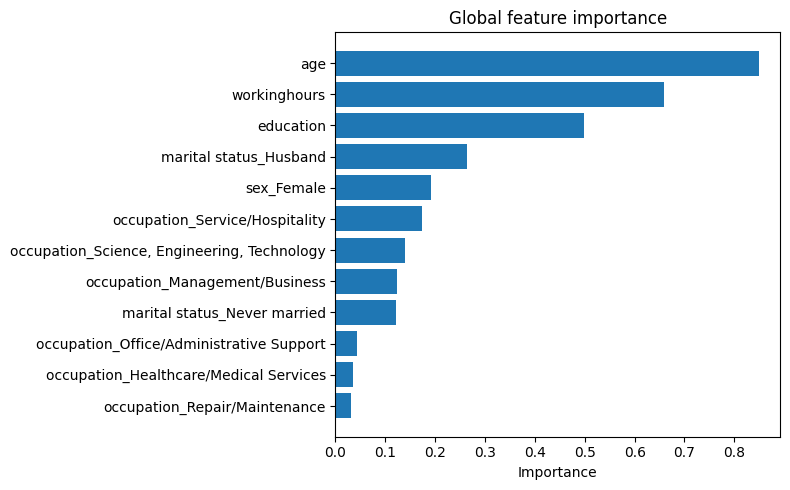

In [4]:
def clean_feature_name(name):
    return str(name).replace('numeric__', '').replace('categorical__', '')

preprocessor = validation_pipeline.named_steps['preprocessor']
model = validation_pipeline.named_steps['model']
X_train_encoded = preprocessor.transform(X_train[final_features])
X_val_encoded = preprocessor.transform(X_val[final_features])
feature_names = [clean_feature_name(name) for name in preprocessor.get_feature_names_out()]

explainability_method = 'shap'
shap_values_for_local = None
try:
    import shap

    explainer = shap.Explainer(model, X_train_encoded, feature_names=feature_names)
    shap_explanation = explainer(X_val_encoded)
    values = np.asarray(shap_explanation.values)
    if values.ndim == 3:
        values = values[:, :, positive_index]
    shap_values_for_local = values
    global_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.abs(values).mean(axis=0),
        'method': 'shap_mean_abs',
    }).sort_values('importance', ascending=False)
except Exception as error:
    explainability_method = 'lime_fallback'
    shap_error = repr(error)
    result = permutation_importance(
        validation_pipeline,
        X_val[final_features],
        y_val,
        scoring='roc_auc',
        n_repeats=5,
        random_state=RANDOM_STATE,
    )
    global_importance = pd.DataFrame({
        'feature': final_features,
        'importance': result.importances_mean,
        'method': 'permutation_importance_auc',
    }).sort_values('importance', ascending=False)

global_importance.to_csv(OUTPUTS_DIR / 'explainability_global_importance.csv', index=False)
fig, ax = plt.subplots(figsize=(8, 5))
plot_data = global_importance.head(12).iloc[::-1]
ax.barh(plot_data['feature'], plot_data['importance'])
ax.set_title('Global feature importance')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150)
display(global_importance.head(15))
print('explainability method:', explainability_method)

In [5]:
def write_shap_local_explanation(label, row_index):
    position = list(X_val.index).index(row_index)
    explanation = pd.DataFrame({
        'feature': feature_names,
        'contribution': shap_values_for_local[position],
        'method': 'shap',
    }).assign(abs_contribution=lambda df: df['contribution'].abs())
    explanation = explanation.sort_values('abs_contribution', ascending=False).drop(columns=['abs_contribution']).head(12)
    explanation.to_csv(OUTPUTS_DIR / f'explainability_local_{label}.csv', index=False)
    return explanation

def write_lime_local_explanation(label, row_index):
    from lime.lime_tabular import LimeTabularExplainer

    training_array = np.asarray(X_train_encoded)
    explainer = LimeTabularExplainer(
        training_array,
        feature_names=feature_names,
        class_names=list(validation_pipeline.classes_),
        mode='classification',
        random_state=RANDOM_STATE,
    )
    row_position = list(X_val.index).index(row_index)
    explanation = explainer.explain_instance(
        np.asarray(X_val_encoded[row_position]),
        model.predict_proba,
        labels=[positive_index],
        num_features=12,
    )
    local = pd.DataFrame(explanation.as_list(label=positive_index), columns=['feature', 'contribution'])
    local['method'] = 'lime'
    local.to_csv(OUTPUTS_DIR / f'explainability_local_{label}.csv', index=False)
    return local

local_outputs = {}
for label, row_index in local_examples.items():
    if explainability_method == 'shap' and shap_values_for_local is not None:
        local_outputs[label] = write_shap_local_explanation(label, row_index)
    else:
        local_outputs[label] = write_lime_local_explanation(label, row_index)
    print(label, 'row', row_index, 'true', y_val.loc[row_index], 'pred', val_pred.loc[row_index], 'positive_score', round(val_positive_score.loc[row_index], 3))
    display(local_outputs[label])

correct_high row 4352 true high pred high positive_score 0.552


,feature,contribution,method
2,workinghours,-1.136988,shap
8,marital status_Husband,-0.410764,shap
1,education,0.386805,shap
0,age,-0.373696,shap
13,occupation_Construction/Extraction,0.159889,shap
31,sex_Female,-0.138221,shap
9,marital status_Never married,-0.133925,shap
29,occupation_Service/Hospitality,-0.081087,shap
28,"occupation_Science, Engineering, Technology",0.074610,shap
21,occupation_Management/Business,0.066796,shap


correct_low row 4505 true low pred low positive_score 0.196


,feature,contribution,method
0,age,-0.897376,shap
1,education,0.719918,shap
2,workinghours,-0.531402,shap
9,marital status_Never married,0.268495,shap
17,"occupation_Farming, Fishing, Forestry",0.254674,shap
8,marital status_Husband,0.216774,shap
31,sex_Female,-0.159935,shap
28,"occupation_Science, Engineering, Technology",0.095541,shap
21,occupation_Management/Business,0.079254,shap
29,occupation_Service/Hospitality,-0.056429,shap


## T10 - Final training and prediction generation

In [6]:
final_pipeline = make_final_pipeline()
final_pipeline.fit(X[final_features], y)
test_predictions = pd.Series(final_pipeline.predict(test_df[final_features]), name='income')

predictions = template.copy()
predictions['income'] = test_predictions.values

if list(predictions.columns) != ['id', 'income']:
    raise ValueError('Prediction columns must be id,income.')
if len(predictions) != len(template) or len(predictions) != len(test_df):
    raise ValueError('Prediction, template, and test row counts must match.')
if not predictions['id'].equals(template['id']):
    raise ValueError('Prediction ids must exactly match template ids.')
if not set(predictions['income']).issubset({'high', 'low'}):
    raise ValueError('Predictions must contain only high/low labels.')

predictions.to_csv(OUTPUTS_DIR / 'predictions.csv', index=False)
summary = pd.DataFrame({
    'metric': ['rows', 'predicted_high_count', 'predicted_high_rate', 'predicted_low_count', 'predicted_low_rate'],
    'value': [
        len(predictions),
        int(predictions['income'].eq('high').sum()),
        float(predictions['income'].eq('high').mean()),
        int(predictions['income'].eq('low').sum()),
        float(predictions['income'].eq('low').mean()),
    ],
})
summary.to_csv(OUTPUTS_DIR / 'prediction_summary.csv', index=False)
display(summary)
display(predictions.head())

,metric,value
0,rows,2000.000
1,predicted_high_count,1028.000
2,predicted_high_rate,0.514
3,predicted_low_count,972.000
4,predicted_low_rate,0.486


,id,income
0,1,high
1,2,high
2,3,high
3,4,low
4,5,high


In [7]:
notes_path = REPORTS_DIR / 'report_notes_tr.md'
existing_notes = notes_path.read_text(encoding='utf-8') if notes_path.exists() else '# Rolling Report Notes\n'
base_notes = existing_notes.split('\n## T9 - Explainability')[0].rstrip()

high_count = int(predictions['income'].eq('high').sum())
high_rate = float(predictions['income'].eq('high').mean())
low_count = int(predictions['income'].eq('low').sum())
method_note = 'SHAP kullanildi.' if explainability_method == 'shap' else f'SHAP calismadigi icin LIME fallback kullanildi; global onem icin permutation importance kullanildi. Hata: {shap_error}'
appendix = f'''
## T9 - Explainability

- Final model icin explainability (aciklanabilirlik) validation seti uzerinde uretildi; `income_test.csv` aciklama veya model secimi icin kullanilmadi.
- {method_note}
- Global feature importance `outputs/explainability_global_importance.csv` ve `outputs/figures/feature_importance.png` olarak uretildi.
- Local explanation dosyalari dogru high ve dogru low validation prediction icin uretildi.

## T10 - Final prediction

- Final pipeline tum `income.csv` uzerinde refit edildi ve `income_test.csv` icin `outputs/predictions.csv` uretildi.
- Predicted high count/rate: {high_count} / {high_rate:.3f}; predicted low count: {low_count}.
- Test accuracy iddia edilmedi; test setinde label olmadigi icin performans yorumu validation/CV sonuclarina dayaniyor.
'''
notes_path.write_text(base_notes + '\n' + appendix, encoding='utf-8')
print(notes_path)

C:\Users\Admin\Storage\Akademik\Dersler\Erasmus Classes\Data Mining\Assignment4\reports\report_notes_tr.md
